In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers = 8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers = 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers = 8)


/user/HS401/ob00564/Documents/COM3001/CK+/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/CK+
cuda
Train set length: 720
Test set length: 89
Validation set length: 93


In [3]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 36, '1': 47, '2': 20, '3': 55, '4': 22, '5': 66, '6': 474}
{'0': 4, '1': 6, '2': 2, '3': 7, '4': 3, '5': 8, '6': 59}
{'0': 5, '1': 6, '2': 3, '3': 7, '4': 3, '5': 9, '6': 60}


In [4]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.mobilenet_v2(weights = 'DEFAULT')
myModel.classifier = torch.nn.Linear(in_features=1280, out_features= 7)
print(myModel)
# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.classifier.parameters():
    param.requires_grad = True

# # Unfreeze 16th, 17th, 18th layers
# for id in range(16,19):
#     for param in myModel.features[id].parameters():
#         param.requires_grad = True
            
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.0001, momentum=0.9, weight_decay= 0.0001)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, 'CK+/Transfer Learning/CK+ MobileNetV2 copy.pth')
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')



100%|██████████| 45/45 [00:01<00:00, 41.15it/s]


Epoch 1/100, Training Loss: 1.9378, Validation Loss: 1.8913
Epoch 1/100, Training Acc: 13.055555555555557, Validation Accuracy: 19.560185185185187


100%|██████████| 45/45 [00:00<00:00, 48.13it/s]


Epoch 2/100, Training Loss: 1.8533, Validation Loss: 1.8162
Epoch 2/100, Training Acc: 31.805555555555554, Validation Accuracy: 42.59259259259259


100%|██████████| 45/45 [00:00<00:00, 47.59it/s]


...

Epoch 51/100, Training Loss: 1.2132, Validation Loss: 1.2444
Epoch 51/100, Training Acc: 65.83333333333333, Validation Accuracy: 68.75


100%|██████████| 45/45 [00:01<00:00, 43.36it/s]


Epoch 52/100, Training Loss: 1.1918, Validation Loss: 1.2358
Epoch 52/100, Training Acc: 65.83333333333333, Validation Accuracy: 68.75


100%|██████████| 45/45 [00:01<00:00, 44.84it/s]


Model saved successfully!
Test Loss: 1.2914, Test Accuracy: 64.52%


Test Loss: 1.2914, Test Accuracy: 64.52%


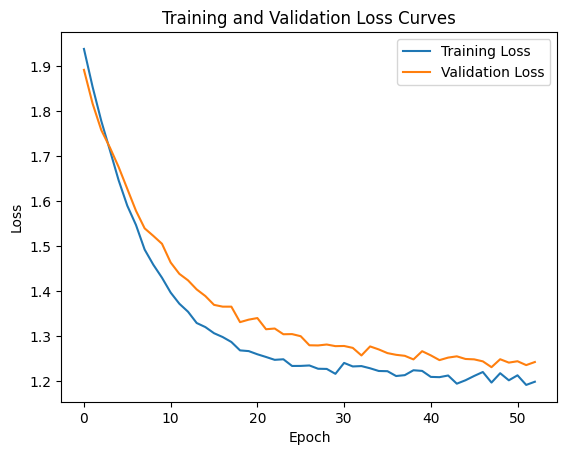

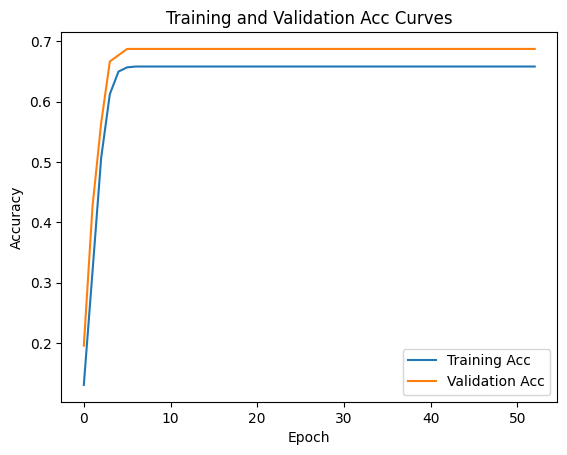

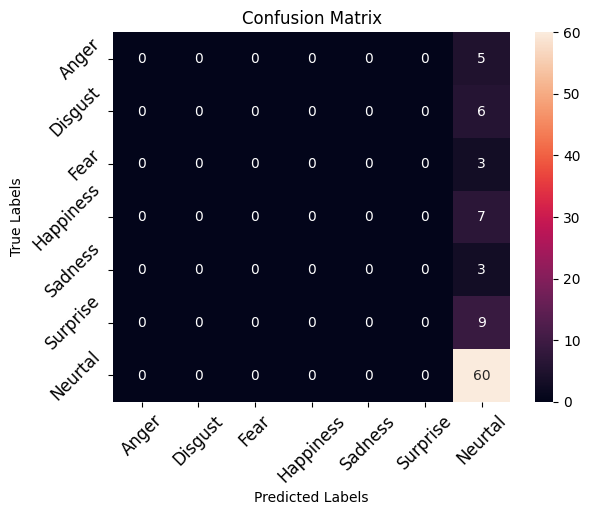

              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         5
     Disgust     0.0000    0.0000    0.0000         6
        Fear     0.0000    0.0000    0.0000         3
   Happiness     0.0000    0.0000    0.0000         7
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     0.0000    0.0000    0.0000         9
     Neurtal     0.6452    1.0000    0.7843        60

    accuracy                         0.6452        93
   macro avg     0.0922    0.1429    0.1120        93
weighted avg     0.4162    0.6452    0.5060        93



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [7]:
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)